# Week 6: Neural Network for Cardiac Disease Classification

This notebook documents the complete Week 6 deep-learning workflow for the cardiac-disease project. It follows the five training days in the Week 6 guide and keeps the neural-network code and experiments that were already present.

The task is binary classification:

- `0`: cardiac disease was not reported.
- `1`: cardiac disease was reported.

The main comparison is between a Logistic Regression baseline and a Keras neural network. ROC-AUC is the main ranking metric, while accuracy, precision, recall, F1-score, and the confusion matrix explain performance at the `0.5` decision threshold.

## Notebook roadmap

| Day | Work documented in this notebook |
|---|---|
| Day 1 | Sprint goal, data loading, train/validation/test split, preprocessing, and baseline setup |
| Day 2 | Activations, network architecture, loss function, and a forward pass |
| Day 3 | Backpropagation, the training loop, class imbalance, learning-rate experiment, and loss curves |
| Day 4 | Keras training and evaluation, Batch Normalization, Dropout, and regularization comparison |
| Day 5 | One-variable-at-a-time tuning, EarlyStopping, ModelCheckpoint, final evaluation, baseline comparison, and retrospective |

## Tools and reproducibility

- **Data:** cleaned 2024 BRFSS cardiac-disease dataset.
- **Data work:** Pandas and NumPy.
- **Preprocessing and baseline:** Scikit-learn.
- **Neural networks:** TensorFlow and Keras.
- **Plots:** Matplotlib.
- **Reproducibility:** `random_state=42` and `tf.keras.utils.set_random_seed(42)` are used where supported.
- **Saved artifact:** `best_cardiac_nn.keras`, produced by `ModelCheckpoint` in Day 5.

This is a documentation and organization pass. It does not introduce a new architecture or add new tuning experiments.


## Day 1 - Sprint Planning, Data Preparation, and Baseline

### Sprint goal

Build a reproducible first neural-network workflow for cardiac-disease classification, then compare it with a simpler Logistic Regression baseline.

### Day 1 backlog

1. Load the cleaned project dataset.
2. Separate the input features from the target.
3. protect a stratified test set and create a validation set.
4. Prepare numeric and categorical columns without data leakage.
5. Fit a Logistic Regression baseline for the final comparison.

### 1.1 Load the cleaned dataset

Pandas reads the prepared CSV file into `df`. The split function is imported now because it is used in the next steps. This cell only creates objects, so no displayed output is expected.


In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split

df = pd.read_csv(
    "../../data/LLCP2024/processed/brfss_2024_cardiac_clean.csv"
)

### 1.2 Separate features and target

`X` contains all patient features. `y` contains only `cardiac_disease`, the value the models must predict. Removing the target from `X` prevents the answer from being given to the model as an input. This assignment also has no displayed output.


In [2]:
X = df.drop(
    columns="cardiac_disease"
)

y = df["cardiac_disease"]

### 1.3 Protect the test set

The first split reserves 20% of the rows for testing. `stratify=y` keeps the class proportions similar in the training and test sets, which matters because class `1` is much less common. `random_state=42` makes the split repeatable.

The test set is not used to fit preprocessing steps or model weights. Later sections report checkpoint and final test results, but tuning decisions are made from validation results.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

### 1.4 Identify numeric and categorical features

The numeric list contains measured quantities such as age, BMI, and health-day counts. The categorical list contains labels such as sex, general health, smoking status, and education. The two groups need different preprocessing steps.


In [4]:
numeric_features = [
    "age",
    "bmi",
    "poor_physical_health_days",
    "poor_mental_health_days",
    "alcohol_days_per_month",
]
categorical_features = [
    "sex",
    "general_health",
    "last_checkup",
    "physical_activity",
    "diabetes_status",
    "stroke_history",
    "kidney_disease",
    "smoking_status",
    "education_level",
    "income_level",
    "employment_status",
    "difficulty_walking",
    "personal_doctor",
    "medical_cost_barrier",
]

### 1.5 Import the preprocessing tools

- `SimpleImputer` fills missing values.
- `StandardScaler` puts numeric features on comparable scales.
- `OneHotEncoder` converts categories into numeric indicator columns.
- `Pipeline` keeps steps in a fixed order.
- `ColumnTransformer` applies the correct pipeline to each column group.

Imports do not produce a displayed result.


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

### 1.6 Build the numeric pipeline

Missing numeric values are replaced with the median, which is less sensitive to extreme values than the mean. The completed columns are then standardized. The pipeline is defined here but is fitted later.


In [6]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
])

### 1.7 Build the categorical pipeline

Missing categories are replaced with the most frequent value in each column. One-hot encoding then creates a separate 0/1 column for every learned category. `handle_unknown="ignore"` allows later data to contain a category that was not present during fitting.


In [7]:
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "one_hot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            dtype="float32",
        )
    ),
])

### 1.8 Combine both preprocessing pipelines

The `ColumnTransformer` sends numeric columns to the numeric pipeline and categorical columns to the categorical pipeline. Keeping this logic in one object makes the same transformations reusable for the baseline and neural network.


In [8]:
preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features,
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features,
    ),
])

### 1.9 Define the baseline

The baseline chains preprocessing with Logistic Regression. `class_weight="balanced"` gives more importance to the minority class, and `max_iter=2000` gives the optimizer enough iterations to converge. The baseline is intentionally simpler than the neural network.


In [9]:
from sklearn.linear_model import LogisticRegression

baseline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42,
        )
    ),
])

### 1.10 Fit the baseline

Calling `fit` learns the preprocessing values from the training data and then trains Logistic Regression. The displayed `Pipeline(...)` is the fitted object returned by Scikit-learn. It confirms that the complete pipeline ran successfully; it is not a performance score. Baseline metrics are calculated in Day 5 on the same test set used for the neural network comparison.


In [10]:
baseline.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 1.11 Create a validation set

The original training portion is split again. The resulting proportions are 70% for neural-network training, 10% for validation, and 20% for testing. The validation set guides choices such as learning rate, stopping point, and dropout rate.


In [11]:
X_train_nn, X_val, y_train_nn, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.125,
    stratify=y_train,
    random_state=42,
)

### 1.12 Fit preprocessing without leakage

`clone` creates a fresh copy of the preprocessor. It is fitted only on `X_train_nn`; the validation and test data are transformed using the values learned from that training subset. This prevents their medians, scales, or categories from influencing training.


In [12]:
from sklearn.base import clone

nn_preprocessor = clone(preprocessor)
X_train_nn_processed = nn_preprocessor.fit_transform(X_train_nn)
X_val_processed = nn_preprocessor.transform(X_val)
X_test_processed = nn_preprocessor.transform(X_test)

### 1.13 Check the transformed shapes

The shape output reports `(rows, columns)` for each transformed array.


In [13]:
print(X_train_nn_processed.shape)
print(X_val_processed.shape)
print(X_test_processed.shape)

(316724, 61)
(45247, 61)
(90493, 61)


**Recorded output:**

- Training: 316,724 patients and 61 processed features.
- Validation: 45,247 patients and the same 61 features.
- Test: 90,493 patients and the same 61 features.

The matching column count confirms that the fitted preprocessor created a consistent input format for every split.


## Day 2 - Activations, Forward Propagation, and Loss

### 2.1 Network design

A neuron calculates a weighted sum, adds a bias, and passes the result through an activation function. Stacking neurons in layers lets the model learn combinations of the 61 processed inputs.

| Part | Choice | Reason |
|---|---|---|
| Input | 61 values | One value for each processed feature |
| Hidden layer 1 | 64 neurons with ReLU | Learns non-linear feature combinations |
| Hidden layer 2 | 32 neurons with ReLU | Compresses the learned representation |
| Output | 1 neuron with sigmoid | Produces a score between 0 and 1 for binary classification |

Without ReLU, several Dense layers would still behave like one linear transformation. Sigmoid is appropriate only at the output here because the task has two classes.


In [14]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

tf.keras.utils.set_random_seed(42)

input_dim = X_train_nn_processed.shape[1]

model = Sequential([
    Input(shape=(input_dim,)),

    Dense(
        64,
        activation="relu"
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,081 (23.75 KB)

 Trainable params: 6,081 (23.75 KB)

 Non-trainable params: 0 (0.00 B)

### 2.2 Read the model summary

The model summary shows three Dense layers and **6,081 trainable parameters**:

- First layer: `(61 inputs x 64 neurons) + 64 biases = 3,968` parameters.
- Second layer: `(64 x 32) + 32 biases = 2,080` parameters.
- Output layer: `(32 x 1) + 1 bias = 33` parameters.

All parameters are trainable, so there are no frozen weights in this first network.


### 2.3 Choose the optimizer, loss, and metrics

- **Adam** applies gradient-based weight updates and adapts the step size for each parameter.
- **Learning rate `0.001`** controls the update size.
- **Binary cross-entropy** matches a sigmoid output and a binary target.
- **Accuracy** measures correct decisions at the default threshold.
- **ROC-AUC** measures ranking quality across possible thresholds.

`compile` configures training but does not fit any weights, so it normally has no result to display. On native Windows, TensorFlow may print a GPU warning; that only means this run uses the CPU and is not a model error.


In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
    ],
)

### 2.4 Make a forward pass before training

One validation patient is sent through the randomly initialized network. This checks that the full input-to-output path works before learning begins.


In [16]:
sample = X_val_processed[:1]

prediction_before_training = model.predict(
    sample,
    verbose=0
)[0][0]

print(
    f"Prediction before training: "
    f"{prediction_before_training:.4f}"
)

print(
    f"Actual class: "
    f"{y_val.iloc[0]}"
)

Prediction before training: 0.5494
Actual class: 0


**Recorded output:** the untrained model gives this patient a score of `0.5494`, while the actual class is `0`. The score is not meaningful yet because the weights are still random; it is only a successful forward-pass check.


## Day 3 - Backpropagation, Optimizers, and Training Behavior

### 3.1 The four-step training loop

Each batch repeats the same process:

1. **Forward pass:** calculate predictions.
2. **Loss calculation:** compare predictions with the true labels.
3. **Backpropagation:** use the chain rule to find how each weight affected the loss.
4. **Optimizer update:** Adam changes the weights in the direction that should reduce the loss.

An **epoch** is one full pass through the training data. A **batch** is the smaller group processed before one weight update. The first run uses 20 epochs and batches of 256 patients.


In [17]:
history = model.fit(
    X_train_nn_processed,
    y_train_nn,
    validation_data=(
        X_val_processed,
        y_val,
    ),
    epochs=20,
    batch_size=256,
    verbose=2,
)

Epoch 1/20


1238/1238 - 2s - 2ms/step - accuracy: 0.9072 - auc: 0.8253 - loss: 0.2478 - val_accuracy: 0.9081 - val_auc: 0.8380 - val_loss: 0.2410


Epoch 2/20


1238/1238 - 1s - 958us/step - accuracy: 0.9085 - auc: 0.8393 - loss: 0.2403 - val_accuracy: 0.9087 - val_auc: 0.8389 - val_loss: 0.2404


Epoch 3/20


1238/1238 - 1s - 965us/step - accuracy: 0.9086 - auc: 0.8407 - loss: 0.2396 - val_accuracy: 0.9085 - val_auc: 0.8388 - val_loss: 0.2405


Epoch 4/20


1238/1238 - 2s - 2ms/step - accuracy: 0.9088 - auc: 0.8415 - loss: 0.2391 - val_accuracy: 0.9084 - val_auc: 0.8387 - val_loss: 0.2406


Epoch 5/20


1238/1238 - 3s - 2ms/step - accuracy: 0.9090 - auc: 0.8422 - loss: 0.2387 - val_accuracy: 0.9085 - val_auc: 0.8388 - val_loss: 0.2407


Epoch 6/20


1238/1238 - 2s - 2ms/step - accuracy: 0.9092 - auc: 0.8428 - loss: 0.2383 - val_accuracy: 0.9085 - val_auc: 0.8386 - val_loss: 0.2407


Epoch 7/20


1238/1238 - 3s - 3ms/step - accuracy: 0.9093 - auc: 0.8436 - loss: 0.2379 - val_accuracy: 0.9081 - val_auc: 0.8384 - val_loss: 0.2409


Epoch 8/20


1238/1238 - 3s - 3ms/step - accuracy: 0.9093 - auc: 0.8441 - loss: 0.2376 - val_accuracy: 0.9084 - val_auc: 0.8383 - val_loss: 0.2410


Epoch 9/20


1238/1238 - 3s - 3ms/step - accuracy: 0.9095 - auc: 0.8446 - loss: 0.2372 - val_accuracy: 0.9083 - val_auc: 0.8384 - val_loss: 0.2411


Epoch 10/20


1238/1238 - 5s - 4ms/step - accuracy: 0.9096 - auc: 0.8451 - loss: 0.2370 - val_accuracy: 0.9085 - val_auc: 0.8382 - val_loss: 0.2412


Epoch 11/20


1238/1238 - 5s - 4ms/step - accuracy: 0.9097 - auc: 0.8456 - loss: 0.2367 - val_accuracy: 0.9081 - val_auc: 0.8380 - val_loss: 0.2414


Epoch 12/20


1238/1238 - 5s - 4ms/step - accuracy: 0.9099 - auc: 0.8461 - loss: 0.2364 - val_accuracy: 0.9083 - val_auc: 0.8377 - val_loss: 0.2416


Epoch 13/20


1238/1238 - 5s - 4ms/step - accuracy: 0.9099 - auc: 0.8465 - loss: 0.2361 - val_accuracy: 0.9084 - val_auc: 0.8372 - val_loss: 0.2419


Epoch 14/20


1238/1238 - 6s - 4ms/step - accuracy: 0.9101 - auc: 0.8470 - loss: 0.2359 - val_accuracy: 0.9085 - val_auc: 0.8368 - val_loss: 0.2420


Epoch 15/20


1238/1238 - 3s - 3ms/step - accuracy: 0.9101 - auc: 0.8474 - loss: 0.2356 - val_accuracy: 0.9084 - val_auc: 0.8365 - val_loss: 0.2422


Epoch 16/20


1238/1238 - 5s - 4ms/step - accuracy: 0.9101 - auc: 0.8477 - loss: 0.2354 - val_accuracy: 0.9085 - val_auc: 0.8361 - val_loss: 0.2425


Epoch 17/20


1238/1238 - 5s - 4ms/step - accuracy: 0.9103 - auc: 0.8482 - loss: 0.2351 - val_accuracy: 0.9080 - val_auc: 0.8356 - val_loss: 0.2428


Epoch 18/20


1238/1238 - 5s - 4ms/step - accuracy: 0.9105 - auc: 0.8485 - loss: 0.2348 - val_accuracy: 0.9077 - val_auc: 0.8350 - val_loss: 0.2432


Epoch 19/20


1238/1238 - 5s - 4ms/step - accuracy: 0.9105 - auc: 0.8489 - loss: 0.2346 - val_accuracy: 0.9077 - val_auc: 0.8348 - val_loss: 0.2434


Epoch 20/20


1238/1238 - 3s - 2ms/step - accuracy: 0.9106 - auc: 0.8492 - loss: 0.2344 - val_accuracy: 0.9075 - val_auc: 0.8343 - val_loss: 0.2437


### 3.2 Read the first training output

The first epoch starts with training loss `0.2478` and validation loss `0.2410`. By epoch 20, training loss falls to `0.2344`, but validation loss rises to `0.2437`. Training ROC-AUC improves from `0.8253` to `0.8492`, while validation ROC-AUC peaks early around `0.8389` and ends at `0.8343`.

The model keeps fitting the training data while validation performance stops improving. This is an early sign of overfitting and explains why later runs use EarlyStopping.


### 3.3 Repeat the same forward pass after training

The same validation patient is used again so the only important difference is that the weights have now been learned.


In [18]:
prediction_after_training = model.predict(
    sample,
    verbose=0
)[0][0]

print(
    f"Before training: "
    f"{prediction_before_training:.4f}"
)

print(
    f"After training: "
    f"{prediction_after_training:.4f}"
)

print(
    f"Actual class: "
    f"{y_val.iloc[0]}"
)

Before training: 0.5494
After training: 0.0478
Actual class: 0


**Recorded output:** the score moves from `0.5494` before training to `0.0478` after training, and the actual class is `0`. The trained score is consistent with this example, but one patient cannot measure overall model quality.


### 3.4 Plot training and validation loss

The loss curves make the gap between training and validation behavior easier to see. A widening gap means additional epochs are helping the training data more than unseen validation data.


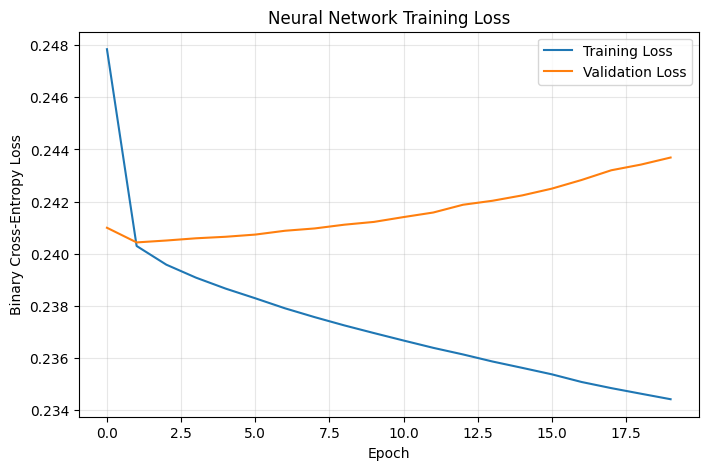

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Neural Network Training Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 3.5 Plot training and validation ROC-AUC

This plot shows ranking performance at every epoch. The training curve continues upward, but the validation curve reaches its best area early and then declines slightly.


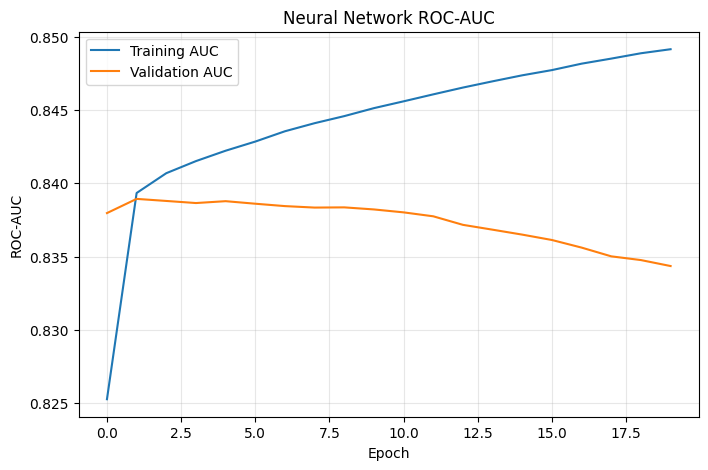

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["auc"],
    label="Training AUC"
)

plt.plot(
    history.history["val_auc"],
    label="Validation AUC"
)

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("Neural Network ROC-AUC")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

**Plot interpretation:** both figures tell the same story. Useful learning happens in the first few epochs; longer training mainly increases the gap between training and validation performance.


### 3.6 Configure EarlyStopping

EarlyStopping watches validation loss. If it does not improve for three epochs, training stops and `restore_best_weights=True` returns the weights from the lowest validation-loss epoch. Creating the callback produces no displayed output.


In [21]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

### 3.7 Create a reusable model function

The function rebuilds the same 64-32-1 architecture and accepts a learning rate. A fresh model is required for each fair learning-rate run so experiments do not continue from weights learned by a previous run.


In [22]:
def create_model(learning_rate=0.001):
    model = Sequential([
        Input(
            shape=(
                X_train_nn_processed.shape[1],
            )
        ),
        Dense(
            64,
            activation="relu"
        ),
        Dense(
            32,
            activation="relu"
        ),
        Dense(
            1,
            activation="sigmoid"
        ),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(
                name="auc"
            ),
        ],
    )

    return model

### 3.8 Account for class imbalance

Balanced class weights are calculated from the neural-network training labels. A class with fewer examples receives more weight, so missing a class-1 case has a larger effect on the training loss.


In [23]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_nn)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_nn,
)

class_weights = dict(
    zip(classes, weights)
)

print(class_weights)

{np.int64(0): np.float64(0.5516148358691412), np.int64(1): np.float64(5.34356863274396)}


**Recorded output:** class `0` receives weight `0.5516`, while class `1` receives weight `5.3436`. The large difference confirms that class `1` is the minority. This choice usually improves minority recall but can also increase false positives.


### 3.9 Compare three learning rates

Three fresh models use the same data, architecture, batch size, class weights, and stopping rule. Only the learning rate changes: `0.00001`, `0.001`, or `0.1`. Keeping all other settings fixed makes this a controlled experiment.

`verbose=0` hides the epoch-by-epoch logs, so the cell prints only the name of each completed experiment. The history objects retain the metrics for the plot.


In [24]:
learning_rates = {
    "1e-5": 0.00001,
    "1e-3": 0.001,
    "1e-1": 0.1,
}

histories = {}

for name, lr in learning_rates.items():

    print(
        f"\nTraining: {name} "
        f"(learning_rate={lr})"
    )

    tf.keras.utils.set_random_seed(42)

    experiment_model = create_model(lr)

    histories[name] = experiment_model.fit(
    X_train_nn_processed,
    y_train_nn,
    validation_data=(
        X_val_processed,
        y_val,
    ),
    epochs=10,
    batch_size=256,
    class_weight=class_weights,
    verbose=0,
)


Training: 1e-5 (learning_rate=1e-05)



Training: 1e-3 (learning_rate=0.001)



Training: 1e-1 (learning_rate=0.1)


### 3.10 Plot the validation-loss comparison


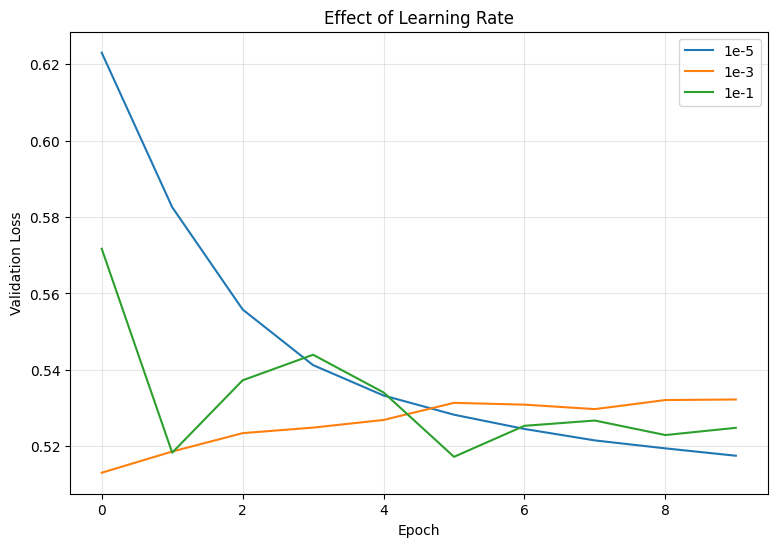

In [25]:
plt.figure(figsize=(9, 6))

for name, lr_history in histories.items():
    plt.plot(
        lr_history.history["val_loss"],
        label=name,
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Effect of Learning Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Learning-rate result:** `1e-5` improves slowly, `1e-1` is less stable, and `1e-3` reaches the lowest validation-loss area quickly. The next model therefore keeps `0.001`. This is a validation-based choice; the test set is not used to select the learning rate.


## Day 4 - Building, Training, and Regularizing the Keras Network

### 4.1 Rebuild the selected plain network

The random seed is reset and a fresh model is created with learning rate `0.001`. Resetting the model prevents the learning-rate experiments from carrying learned weights into this run.


In [26]:
tf.keras.utils.set_random_seed(42)

final_nn = create_model(
    learning_rate=0.001
)

### 4.2 Train with class weights and EarlyStopping

The maximum is 50 epochs, but EarlyStopping can finish earlier when validation loss stops improving.


In [27]:
history = final_nn.fit(
    X_train_nn_processed,
    y_train_nn,
    validation_data=(
        X_val_processed,
        y_val,
    ),
    epochs=50,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[
        early_stopping
    ],
    verbose=2,
)

Epoch 1/50


1238/1238 - 5s - 4ms/step - accuracy: 0.7255 - auc: 0.8322 - loss: 0.5019 - val_accuracy: 0.7158 - val_auc: 0.8377 - val_loss: 0.5131


Epoch 2/50


1238/1238 - 5s - 4ms/step - accuracy: 0.7266 - auc: 0.8400 - loss: 0.4916 - val_accuracy: 0.7094 - val_auc: 0.8380 - val_loss: 0.5186


Epoch 3/50


1238/1238 - 3s - 3ms/step - accuracy: 0.7268 - auc: 0.8413 - loss: 0.4897 - val_accuracy: 0.7062 - val_auc: 0.8383 - val_loss: 0.5234


Epoch 4/50


1238/1238 - 5s - 4ms/step - accuracy: 0.7273 - auc: 0.8422 - loss: 0.4884 - val_accuracy: 0.7051 - val_auc: 0.8381 - val_loss: 0.5249


**Recorded output:** training stops after 4 epochs because validation loss does not beat the first epoch for three consecutive epochs. The callback restores the best weights. This prevents the remaining 46 possible epochs from adding more overfitting.


### 4.3 Checkpoint evaluation of the plain network

`evaluate` returns loss, accuracy, and ROC-AUC. This provides a reference before adding Batch Normalization and Dropout. Predictions are then converted to classes with a fixed threshold of `0.5`.


In [28]:
test_loss, test_accuracy, test_auc = final_nn.evaluate(
    X_test_processed,
    y_test,
    verbose=0,
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test ROC-AUC: {test_auc:.4f}")

Test Loss: 0.5100
Test Accuracy: 0.7172
Test ROC-AUC: 0.8393


**Recorded output:** test loss is `0.5100`, test accuracy is `0.7172`, and test ROC-AUC is `0.8393`. ROC-AUC shows useful ranking ability, while accuracy is affected by the class weighting and the fixed threshold.


In [29]:
y_prob_nn = final_nn.predict(
    X_test_processed,
    verbose=0
).ravel()

y_pred_nn = (
    y_prob_nn >= 0.5
).astype(int)

The prediction cell stores probability-like scores in `y_prob_nn` and thresholded labels in `y_pred_nn`. It has no displayed output because both results are assigned to variables.


In [30]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

print(
    classification_report(
        y_test,
        y_pred_nn
    )
)

print(
    confusion_matrix(
        y_test,
        y_pred_nn
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_prob_nn
    )
)

              precision    recall  f1-score   support

           0       0.97      0.71      0.82     82025
           1       0.22      0.82      0.35      8468

    accuracy                           0.72     90493
   macro avg       0.60      0.76      0.59     90493
weighted avg       0.90      0.72      0.78     90493

[[57965 24060]
 [ 1530  6938]]
ROC-AUC: 0.8392502134719633


**Checkpoint report:**

- Class `0`: precision `0.97`, recall `0.71`, and F1-score `0.82`.
- Class `1`: precision `0.22`, recall `0.82`, and F1-score `0.35`.
- Confusion matrix: 57,965 true negatives, 24,060 false positives, 1,530 false negatives, and 6,938 true positives.

The model finds 82% of reported cardiac-disease cases, but the 22% precision means many class-1 flags are false positives. This is the main threshold trade-off in the plain model.


### 4.4 Add the existing Batch Normalization and Dropout experiment

The notebook already contained a regularized version of the same network:

- **Batch Normalization** stabilizes intermediate activations.
- **Dropout** randomly disables a fraction of units during training, which reduces reliance on individual paths.

This section documents that existing experiment. It does not add a new architecture during this documentation pass.


In [31]:
from tensorflow.keras.layers import BatchNormalization, Dropout

### 4.5 Define the regularized model

The Dense layer sizes, ReLU activations, sigmoid output, Adam optimizer, loss, and metrics stay consistent. Batch Normalization and Dropout are inserted after each hidden Dense layer. The dropout rate is a function argument so Day 5 can vary only that value.


In [32]:
def create_regularized_model(
    learning_rate=0.001,
    dropout_rate=0.3
):
    model = Sequential([
        Input(
            shape=(
                X_train_nn_processed.shape[1],
            )
        ),

        Dense(
            64,
            activation="relu"
        ),

        BatchNormalization(),

        Dropout(
            dropout_rate
        ),

        Dense(
            32,
            activation="relu"
        ),

        BatchNormalization(),

        Dropout(
            dropout_rate
        ),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(
                name="auc"
            ),
        ],
    )

    return model

### 4.6 Train the regularized model with dropout `0.3`


In [33]:
tf.keras.utils.set_random_seed(42)

regularized_model = create_regularized_model(
    learning_rate=0.001,
    dropout_rate=0.3
)

regularized_history = regularized_model.fit(
    X_train_nn_processed,
    y_train_nn,
    validation_data=(
        X_val_processed,
        y_val
    ),
    epochs=50,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ],
    verbose=2
)

Epoch 1/50


1238/1238 - 8s - 6ms/step - accuracy: 0.6923 - auc: 0.8079 - loss: 0.5366 - val_accuracy: 0.6975 - val_auc: 0.8375 - val_loss: 0.5340


Epoch 2/50


1238/1238 - 10s - 8ms/step - accuracy: 0.7177 - auc: 0.8318 - loss: 0.5034 - val_accuracy: 0.6999 - val_auc: 0.8384 - val_loss: 0.5252


Epoch 3/50


1238/1238 - 5s - 4ms/step - accuracy: 0.7191 - auc: 0.8348 - loss: 0.4990 - val_accuracy: 0.7072 - val_auc: 0.8388 - val_loss: 0.5131


Epoch 4/50


1238/1238 - 9s - 7ms/step - accuracy: 0.7204 - auc: 0.8358 - loss: 0.4978 - val_accuracy: 0.6997 - val_auc: 0.8391 - val_loss: 0.5186


Epoch 5/50


1238/1238 - 3s - 3ms/step - accuracy: 0.7204 - auc: 0.8368 - loss: 0.4964 - val_accuracy: 0.6878 - val_auc: 0.8389 - val_loss: 0.5306


Epoch 6/50


1238/1238 - 8s - 6ms/step - accuracy: 0.7202 - auc: 0.8371 - loss: 0.4960 - val_accuracy: 0.6935 - val_auc: 0.8390 - val_loss: 0.5255


Epoch 7/50


1238/1238 - 9s - 7ms/step - accuracy: 0.7215 - auc: 0.8375 - loss: 0.4952 - val_accuracy: 0.6942 - val_auc: 0.8387 - val_loss: 0.5250


Epoch 8/50


1238/1238 - 6s - 5ms/step - accuracy: 0.7219 - auc: 0.8381 - loss: 0.4947 - val_accuracy: 0.6937 - val_auc: 0.8391 - val_loss: 0.5239


**Recorded output:** this run stops after 8 epochs. Its best validation loss is `0.5131`, and its best validation ROC-AUC is `0.8391`. The validation result is close to the plain network, so regularization changes training behavior without producing a large gain at this setting.


### 4.7 Plot the regularized loss curves


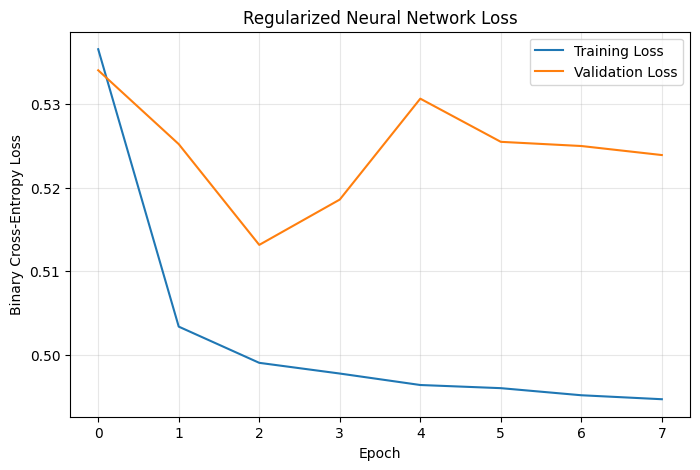

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    regularized_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    regularized_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Regularized Neural Network Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 4.8 Plot the regularized ROC-AUC curves


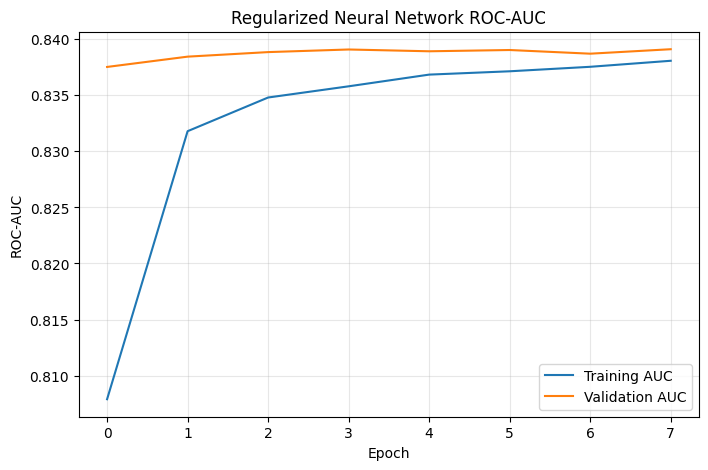

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(
    regularized_history.history["auc"],
    label="Training AUC"
)

plt.plot(
    regularized_history.history["val_auc"],
    label="Validation AUC"
)

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("Regularized Neural Network ROC-AUC")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

The regularized curves fluctuate because Dropout changes the active network during each training batch. Validation metrics are still the correct basis for comparison because Dropout is disabled automatically during validation and prediction.


### 4.9 Compare plain and regularized validation results

The table uses the best validation loss and ROC-AUC reached by each run rather than the last epoch only.


In [36]:
plain_best_val_loss = min(
    history.history["val_loss"]
)

regularized_best_val_loss = min(
    regularized_history.history["val_loss"]
)

plain_best_val_auc = max(
    history.history["val_auc"]
)

regularized_best_val_auc = max(
    regularized_history.history["val_auc"]
)

day4_comparison = pd.DataFrame({
    "model": [
        "Original Neural Network",
        "BatchNorm + Dropout Network"
    ],
    "best_val_loss": [
        plain_best_val_loss,
        regularized_best_val_loss
    ],
    "best_val_auc": [
        plain_best_val_auc,
        regularized_best_val_auc
    ]
})

display(
    day4_comparison.round(4)
)

,model,best_val_loss,best_val_auc
0,Original Neural Network,0.5131,0.8383
1,BatchNorm + Dropout Network,0.5131,0.8391


**Recorded output:** both runs reach best validation loss `0.5131`. The regularized model has a slightly higher best validation ROC-AUC (`0.8391` versus `0.8383`). The difference is small, so this table supports continued controlled tuning rather than a strong claim of improvement.


## Day 5 - Tuning, Final Evaluation, and Sprint Review

### 5.1 Tune one variable at a time

The learning rate remains `0.001`, and the preprocessing, architecture, optimizer, batch size, data, and random seed stay fixed. Only the dropout rate changes among `0.1`, `0.3`, and `0.5`. This makes it easier to connect any validation difference to dropout.


In [37]:
dropout_rates = [
    0.1,
    0.3,
    0.5
]

dropout_results = []
dropout_histories = {}

for rate in dropout_rates:

    print(
        f"\nTraining dropout={rate}"
    )

    tf.keras.utils.set_random_seed(42)

    candidate_model = create_regularized_model(
        learning_rate=0.001,
        dropout_rate=rate
    )

    candidate_history = candidate_model.fit(
        X_train_nn_processed,
        y_train_nn,
        validation_data=(
            X_val_processed,
            y_val
        ),
        epochs=50,
        batch_size=256,
        class_weight=class_weights,
        callbacks=[
            EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True
            )
        ],
        verbose=0
    )

    dropout_histories[rate] = candidate_history

    dropout_results.append({
        "dropout_rate": rate,
        "epochs_trained": len(
            candidate_history.history["loss"]
        ),
        "best_val_loss": min(
            candidate_history.history["val_loss"]
        ),
        "best_val_auc": max(
            candidate_history.history["val_auc"]
        ),
        "best_val_accuracy": max(
            candidate_history.history[
                "val_accuracy"
            ]
        )
    })


Training dropout=0.1



Training dropout=0.3



Training dropout=0.5


The tuning cell prints the three tested rates. Each history is stored, and the best validation values are collected for the table below. No test result is used to choose the dropout rate.


In [38]:
dropout_results_df = pd.DataFrame(
    dropout_results
)

display(
    dropout_results_df
    .sort_values(
        "best_val_auc",
        ascending=False
    )
    .round(4)
)

,dropout_rate,epochs_trained,best_val_loss,best_val_auc,best_val_accuracy
2,0.5,9,0.5068,0.8392,0.7016
1,0.3,8,0.5131,0.8391,0.7072
0,0.1,18,0.5179,0.8389,0.7074


### 5.2 Read the dropout results

| Dropout | Epochs trained | Best validation loss | Best validation ROC-AUC | Best validation accuracy |
|---:|---:|---:|---:|---:|
| 0.5 | 9 | 0.5068 | 0.8392 | 0.7016 |
| 0.3 | 8 | 0.5131 | 0.8391 | 0.7072 |
| 0.1 | 18 | 0.5179 | 0.8389 | 0.7074 |

Dropout `0.5` has the best validation ROC-AUC and lowest validation loss in this controlled comparison, so the existing selection rule chooses it. Its validation accuracy is lower, which again shows why one metric does not tell the whole story.


### 5.3 Plot all dropout validation-loss curves


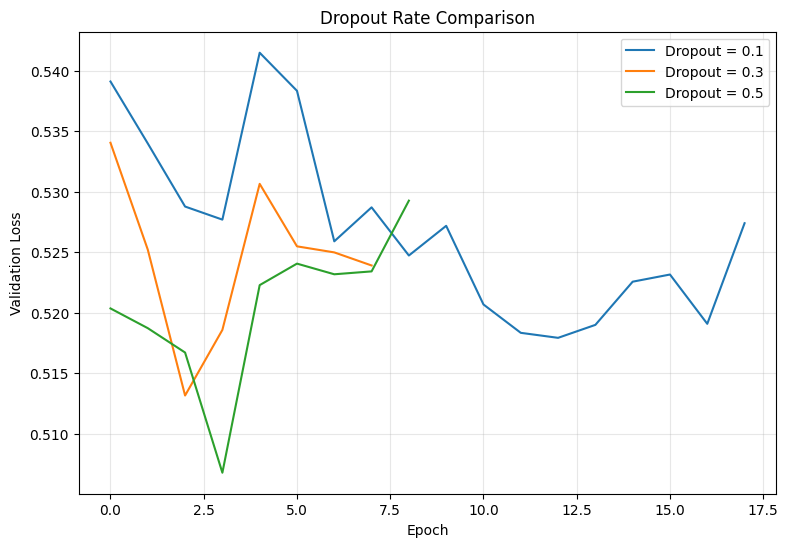

In [39]:
plt.figure(figsize=(9, 6))

for rate, candidate_history in dropout_histories.items():

    plt.plot(
        candidate_history.history["val_loss"],
        label=f"Dropout = {rate}"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Dropout Rate Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

The curve plot shows when each setting reaches its best validation loss and how quickly it begins to overfit or fluctuate. It supports the values summarized in the table rather than replacing them.


### 5.4 Configure final callbacks

- `EarlyStopping` ends training after five validation-loss epochs without improvement and restores the best weights.
- `ModelCheckpoint` writes the lowest-validation-loss model to `best_cardiac_nn.keras`.

The import cell and callback setup cell only create objects, so neither is expected to display a result.


In [40]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

In [41]:
checkpoint_path = "best_cardiac_nn.keras"

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

### 5.5 Select the dropout rate from validation results


In [42]:
best_dropout = (
    dropout_results_df
    .sort_values(
        "best_val_auc",
        ascending=False
    )
    .iloc[0]["dropout_rate"]
)

print(
    f"Selected dropout rate: "
    f"{best_dropout}"
)

Selected dropout rate: 0.5


**Recorded output:** the selected dropout rate is `0.5`, matching the highest best validation ROC-AUC in the results table.


### 5.6 Train and save the selected model

The selected model is rebuilt from fresh seeded weights and allowed up to 100 epochs. EarlyStopping controls the stopping point, while ModelCheckpoint keeps the lowest-validation-loss file.


In [43]:
tf.keras.utils.set_random_seed(42)

best_nn = create_regularized_model(
    learning_rate=0.001,
    dropout_rate=float(
        best_dropout
    )
)

best_history = best_nn.fit(
    X_train_nn_processed,
    y_train_nn,
    validation_data=(
        X_val_processed,
        y_val
    ),
    epochs=100,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[
        early_stopping,
        checkpoint
    ],
    verbose=2
)

Epoch 1/100



Epoch 1: val_loss improved from None to 0.52035, saving model to best_cardiac_nn.keras



Epoch 1: finished saving model to best_cardiac_nn.keras


1238/1238 - 8s - 7ms/step - accuracy: 0.6780 - auc: 0.7891 - loss: 0.5628 - val_accuracy: 0.6994 - val_auc: 0.8371 - val_loss: 0.5203


Epoch 2/100



Epoch 2: val_loss improved from 0.52035 to 0.51871, saving model to best_cardiac_nn.keras



Epoch 2: finished saving model to best_cardiac_nn.keras


1238/1238 - 5s - 4ms/step - accuracy: 0.7127 - auc: 0.8261 - loss: 0.5117 - val_accuracy: 0.6996 - val_auc: 0.8384 - val_loss: 0.5187


Epoch 3/100



Epoch 3: val_loss improved from 0.51871 to 0.51670, saving model to best_cardiac_nn.keras



Epoch 3: finished saving model to best_cardiac_nn.keras


1238/1238 - 5s - 4ms/step - accuracy: 0.7161 - auc: 0.8301 - loss: 0.5061 - val_accuracy: 0.6977 - val_auc: 0.8387 - val_loss: 0.5167


Epoch 4/100



Epoch 4: val_loss improved from 0.51670 to 0.50677, saving model to best_cardiac_nn.keras



Epoch 4: finished saving model to best_cardiac_nn.keras


1238/1238 - 5s - 4ms/step - accuracy: 0.7160 - auc: 0.8315 - loss: 0.5041 - val_accuracy: 0.7016 - val_auc: 0.8388 - val_loss: 0.5068


Epoch 5/100



Epoch 5: val_loss did not improve from 0.50677


1238/1238 - 10s - 8ms/step - accuracy: 0.7180 - auc: 0.8326 - loss: 0.5032 - val_accuracy: 0.6909 - val_auc: 0.8390 - val_loss: 0.5223


Epoch 6/100



Epoch 6: val_loss did not improve from 0.50677


1238/1238 - 4s - 3ms/step - accuracy: 0.7168 - auc: 0.8335 - loss: 0.5016 - val_accuracy: 0.6914 - val_auc: 0.8391 - val_loss: 0.5240


Epoch 7/100



Epoch 7: val_loss did not improve from 0.50677


1238/1238 - 4s - 4ms/step - accuracy: 0.7177 - auc: 0.8334 - loss: 0.5016 - val_accuracy: 0.6892 - val_auc: 0.8389 - val_loss: 0.5232


Epoch 8/100



Epoch 8: val_loss did not improve from 0.50677


1238/1238 - 4s - 3ms/step - accuracy: 0.7168 - auc: 0.8336 - loss: 0.5016 - val_accuracy: 0.6893 - val_auc: 0.8390 - val_loss: 0.5234


Epoch 9/100



Epoch 9: val_loss did not improve from 0.50677


1238/1238 - 4s - 3ms/step - accuracy: 0.7170 - auc: 0.8346 - loss: 0.4998 - val_accuracy: 0.6858 - val_auc: 0.8392 - val_loss: 0.5293


**Recorded output:** validation loss improves through epoch 4, where it reaches `0.50677` and the checkpoint is saved. The next five epochs do not improve it, so training stops after epoch 9. The saved artifact therefore represents epoch 4 rather than the final epoch shown in the log.


### 5.7 Load and evaluate the saved checkpoint

Loading the file verifies that evaluation uses the checkpoint selected by validation loss.


In [44]:
best_model = tf.keras.models.load_model(
    checkpoint_path
)

test_loss, test_accuracy, test_auc = (
    best_model.evaluate(
        X_test_processed,
        y_test,
        verbose=0
    )
)

print(
    f"Test Loss: {test_loss:.4f}"
)

print(
    f"Test Accuracy: {test_accuracy:.4f}"
)

print(
    f"Test ROC-AUC: {test_auc:.4f}"
)

Test Loss: 0.5035
Test Accuracy: 0.7038
Test ROC-AUC: 0.8402


**Recorded output:** the saved model reaches test loss `0.5035`, test accuracy `0.7038`, and test ROC-AUC `0.8402`. Compared with the plain checkpoint, ROC-AUC improves slightly while accuracy decreases. This is a trade-off, not a clear improvement on every metric.


### 5.8 Create final class predictions

The saved model generates one score per test patient. Scores at or above `0.5` become class `1`; lower scores become class `0`. The cell stores arrays and therefore has no displayed output.


In [45]:
y_prob_nn = best_model.predict(
    X_test_processed,
    verbose=0
).ravel()

y_pred_nn = (
    y_prob_nn >= 0.5
).astype(int)

### 5.9 Read the final classification report


In [46]:
print(
    classification_report(
        y_test,
        y_pred_nn
    )
)

print(
    confusion_matrix(
        y_test,
        y_pred_nn
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_prob_nn
    )
)

              precision    recall  f1-score   support

           0       0.98      0.69      0.81     82025
           1       0.22      0.84      0.35      8468

    accuracy                           0.70     90493
   macro avg       0.60      0.76      0.58     90493
weighted avg       0.91      0.70      0.77     90493

[[56611 25414]
 [ 1386  7082]]
ROC-AUC: 0.8402380779273804


**Recorded output:**

- Class `0`: precision `0.98`, recall `0.69`, and F1-score `0.81`.
- Class `1`: precision `0.22`, recall `0.84`, and F1-score `0.35`.
- Confusion matrix: 56,611 true negatives, 25,414 false positives, 1,386 false negatives, and 7,082 true positives.

The regularized model detects 84% of class-1 cases, two percentage points more than the plain model, but it produces more false positives and lower overall accuracy. Threshold choice would need to reflect the real project cost of missed cases versus false alarms.


### 5.10 Evaluate the Logistic Regression baseline

The fitted baseline produces probabilities and `0.5`-threshold predictions on the same test rows. Accuracy and ROC-AUC are calculated for a direct comparison.


In [47]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score
)

baseline_prob = baseline.predict_proba(
    X_test
)[:, 1]

baseline_pred = baseline.predict(
    X_test
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

baseline_auc = roc_auc_score(
    y_test,
    baseline_prob
)

print(
    f"Baseline Accuracy: "
    f"{baseline_accuracy:.4f}"
)

print(
    f"Baseline ROC-AUC: "
    f"{baseline_auc:.4f}"
)

Baseline Accuracy: 0.7438
Baseline ROC-AUC: 0.8380


**Recorded output:** Logistic Regression reaches test accuracy `0.7438` and test ROC-AUC `0.8380`.


### 5.11 Final model comparison


In [48]:
final_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "test_accuracy": baseline_accuracy,
        "test_roc_auc": baseline_auc
    },
    {
        "model": "Neural Network",
        "test_accuracy": test_accuracy,
        "test_roc_auc": test_auc
    }
])

display(
    final_comparison
    .sort_values(
        "test_roc_auc",
        ascending=False
    )
    .round(4)
)

,model,test_accuracy,test_roc_auc
1,Neural Network,0.7038,0.8402
0,Logistic Regression,0.7438,0.8380


## Sprint 1 review

| Model | Test accuracy | Test ROC-AUC |
|---|---:|---:|
| Logistic Regression | 0.7438 | 0.8380 |
| Neural Network | 0.7038 | 0.8402 |

The neural network has the higher ROC-AUC by about `0.0022`, while Logistic Regression has the higher accuracy by `0.0400`. The gain in ranking performance is very small, so the additional neural-network complexity is not clearly justified by these results alone. The final classification report also shows that the `0.5` threshold favors class-1 recall at the cost of many false positives.

## Sprint retrospective

### What went well

- The same leakage-safe preprocessing logic was used across all data splits.
- The model used the correct sigmoid output and binary cross-entropy loss for binary classification.
- Learning rate and dropout were changed one at a time.
- EarlyStopping and ModelCheckpoint kept the best validation-loss weights.
- The final neural network was compared with a simpler baseline using the same test data.

### What could be improved later

- The ROC-AUC improvement over Logistic Regression is very small.
- Class-1 precision is low at the fixed `0.5` threshold.
- Future work should examine threshold selection and stronger experiment tracking before making a practical decision.

### Next Sprint 2 action

Record every future experiment's architecture, learning rate, dropout, stopping epoch, validation metrics, and test metrics in one consistent table before attempting any new neural-network enhancement.

## Final conclusion

The Week 6 workflow is complete and reproducible. It starts with a baseline, explains how the network makes and learns from predictions, reads the training curves, applies the existing regularization and tuning steps, saves the best checkpoint, and compares final results honestly. The current neural network slightly improves ROC-AUC but does not improve accuracy, so further enhancement should be treated as a separate next step.


## Neural Network Enhancement

### Why the model needs enhancement

The documented neural network reaches test ROC-AUC `0.8402`, but its test accuracy is only `0.7038`. The class-1 recall is strong at `0.84`, while class-1 precision is only `0.22`. The confusion matrix explains the problem: the model finds many cardiac-disease cases, but it also creates 25,414 false positives.

This happens mainly because the original balanced class weights make class-1 errors much more expensive than class-0 errors. That is useful for recall, but it pushes the model toward predicting class `1` more often. The fixed `0.5` threshold then converts many of those scores into positive predictions.

The enhancement should therefore improve the decision balance, not simply add more layers. A larger network would not directly solve the false-positive problem and could create more overfitting.

### Enhancement goals

The enhancement uses the validation set to pursue three goals:

1. Increase accuracy by reducing false positives.
2. Keep class-1 recall at or above `0.75`, so the model still detects most reported cases.
3. Preserve ranking performance, measured with ROC-AUC and PR-AUC.

The `0.75` recall requirement prevents the search from obtaining high accuracy by predicting almost every patient as class `0`.

### What will change and why

- **Positive-class weight:** several values are tested because the original weighting may be too aggressive.
- **Decision threshold:** each candidate receives a validation-selected threshold instead of assuming `0.5` is best.
- **ReduceLROnPlateau:** the learning rate is reduced when validation loss stalls, allowing smaller late-training updates.
- **EarlyStopping:** training still stops when validation loss no longer improves, which limits overfitting and wasted epochs.

The existing regularized architecture and selected dropout rate remain fixed. This keeps the experiment controlled: the main training change is class weighting, followed by a threshold chosen under the same recall rule for every candidate.

> The test set is not used to select a class weight or threshold. It is evaluated only after the validation-based choice is complete. Because earlier notebook sections already reported test results, this remains a continuation comparison rather than a brand-new unseen benchmark.


### 1. Import the enhancement metrics and callback

Accuracy alone is not enough for an imbalanced target. The enhancement also records precision, recall, F1-score, balanced accuracy, ROC-AUC, and PR-AUC. `ReduceLROnPlateau` provides the safer learning-rate schedule described above.


In [49]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from tensorflow.keras.callbacks import ReduceLROnPlateau


### 2. Define validation-based threshold selection

The function checks thresholds from `0.05` to `0.95`. It first keeps only thresholds with class-1 recall of at least `0.75`, then chooses the one with the highest accuracy. F1-score and balanced accuracy are used as tie-breakers.

The threshold is chosen from validation predictions only. This prevents test results from controlling the decision rule.


In [50]:
def select_threshold_with_recall_guard(
    y_true,
    probabilities,
    minimum_recall=0.75,
):
    threshold_rows = []

    for threshold in np.arange(0.05, 0.951, 0.01):
        predictions = (
            probabilities >= threshold
        ).astype(int)

        threshold_rows.append({
            "threshold": float(threshold),
            "accuracy": accuracy_score(
                y_true,
                predictions,
            ),
            "precision": precision_score(
                y_true,
                predictions,
                zero_division=0,
            ),
            "recall": recall_score(
                y_true,
                predictions,
                zero_division=0,
            ),
            "f1": f1_score(
                y_true,
                predictions,
                zero_division=0,
            ),
            "balanced_accuracy": balanced_accuracy_score(
                y_true,
                predictions,
            ),
        })

    threshold_table = pd.DataFrame(threshold_rows)
    eligible = threshold_table[
        threshold_table["recall"] >= minimum_recall
    ]

    if eligible.empty:
        raise ValueError(
            "No threshold satisfied the recall requirement."
        )

    selected = (
        eligible
        .sort_values(
            ["accuracy", "f1", "balanced_accuracy"],
            ascending=False,
        )
        .iloc[0]
    )

    return selected, threshold_table


### 3. Train controlled class-weight candidates

The original balanced weights have a class-1-to-class-0 ratio of about `9.69`. The experiment tests positive-class weights of `1`, `2`, `4`, `6`, and the original relative ratio. Class `0` stays at weight `1` so the values are easy to compare.

Every candidate uses:

- The same processed training and validation data.
- The existing 64-32 regularized architecture.
- Dropout `0.5` and learning rate `0.001`.
- The same batch size and random seed.
- Fresh EarlyStopping and ReduceLROnPlateau callbacks.

After training, the threshold function finds the best validation accuracy that still meets the recall requirement. The printed line confirms how many epochs each candidate needed.


In [51]:
original_positive_ratio = (
    class_weights[1]
    / class_weights[0]
)

positive_weight_candidates = [
    1.0,
    2.0,
    4.0,
    6.0,
    round(float(original_positive_ratio), 2),
]

enhancement_models = {}
enhancement_histories = {}
enhancement_threshold_tables = {}
enhancement_results = []

for positive_weight in positive_weight_candidates:
    tf.keras.utils.set_random_seed(42)

    candidate_model = create_regularized_model(
        learning_rate=0.001,
        dropout_rate=0.5,
    )

    candidate_early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    )
    candidate_lr_schedule = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=0.00001,
        verbose=0,
    )

    candidate_history = candidate_model.fit(
        X_train_nn_processed,
        y_train_nn,
        validation_data=(
            X_val_processed,
            y_val,
        ),
        epochs=40,
        batch_size=256,
        class_weight={
            0: 1.0,
            1: positive_weight,
        },
        callbacks=[
            candidate_early_stopping,
            candidate_lr_schedule,
        ],
        verbose=0,
    )

    validation_probabilities = candidate_model.predict(
        X_val_processed,
        verbose=0,
    ).ravel()

    selected_threshold_row, threshold_table = (
        select_threshold_with_recall_guard(
            y_val,
            validation_probabilities,
            minimum_recall=0.75,
        )
    )

    enhancement_models[positive_weight] = candidate_model
    enhancement_histories[positive_weight] = candidate_history
    enhancement_threshold_tables[positive_weight] = (
        threshold_table
    )

    enhancement_results.append({
        "positive_class_weight": positive_weight,
        "epochs_trained": len(
            candidate_history.history["loss"]
        ),
        "selected_threshold": selected_threshold_row[
            "threshold"
        ],
        "val_accuracy": selected_threshold_row[
            "accuracy"
        ],
        "val_precision": selected_threshold_row[
            "precision"
        ],
        "val_recall": selected_threshold_row[
            "recall"
        ],
        "val_f1": selected_threshold_row["f1"],
        "val_balanced_accuracy": selected_threshold_row[
            "balanced_accuracy"
        ],
        "val_roc_auc": roc_auc_score(
            y_val,
            validation_probabilities,
        ),
        "val_pr_auc": average_precision_score(
            y_val,
            validation_probabilities,
        ),
    })

    print(
        f"Completed positive weight {positive_weight:.2f} "
        f"in {len(candidate_history.history['loss'])} epochs"
    )


Completed positive weight 1.00 in 35 epochs


Completed positive weight 2.00 in 22 epochs


Completed positive weight 4.00 in 22 epochs


Completed positive weight 6.00 in 8 epochs


Completed positive weight 9.69 in 26 epochs


### 4. Compare the validation results

This table is the evidence used for selection. The rows are sorted by validation accuracy, but every row already satisfies the minimum-recall rule at its own selected threshold.


In [52]:
enhancement_results_df = pd.DataFrame(
    enhancement_results
)

display(
    enhancement_results_df
    .sort_values(
        ["val_accuracy", "val_f1"],
        ascending=False,
    )
    .round(4)
)


,positive_class_weight,epochs_trained,selected_threshold,val_accuracy,val_precision,val_recall,val_f1,val_balanced_accuracy,val_roc_auc,val_pr_auc
0,1.00,35,0.12,0.7644,0.2491,0.7534,0.3744,0.7595,0.8396,0.3608
1,2.00,22,0.22,0.7634,0.2487,0.7565,0.3744,0.7603,0.8395,0.3612
2,4.00,22,0.36,0.7613,0.2469,0.7563,0.3722,0.7590,0.8396,0.3607
4,9.69,26,0.58,0.7608,0.2468,0.7581,0.3724,0.7596,0.8396,0.3611
3,6.00,8,0.47,0.7591,0.2453,0.7581,0.3707,0.7587,0.8388,0.3600


The best candidate is selected by validation accuracy, then by F1-score if two candidates have the same accuracy. ROC-AUC and PR-AUC remain reporting metrics so a higher threshold cannot hide weaker probability ranking.


In [53]:
selected_enhancement = (
    enhancement_results_df
    .sort_values(
        ["val_accuracy", "val_f1"],
        ascending=False,
    )
    .iloc[0]
)

selected_positive_weight = float(
    selected_enhancement["positive_class_weight"]
)
selected_enhanced_threshold = float(
    selected_enhancement["selected_threshold"]
)
enhanced_model = enhancement_models[
    selected_positive_weight
]

print(
    "Selected positive-class weight: "
    f"{selected_positive_weight:.2f}"
)
print(
    "Selected validation threshold: "
    f"{selected_enhanced_threshold:.2f}"
)
print(
    "Validation accuracy: "
    f"{selected_enhancement['val_accuracy']:.4f}"
)
print(
    "Validation recall: "
    f"{selected_enhancement['val_recall']:.4f}"
)


Selected positive-class weight: 1.00
Selected validation threshold: 0.12
Validation accuracy: 0.7644
Validation recall: 0.7534


### 5. Visualize the selected threshold trade-off

The plot shows why threshold selection is a trade-off. Raising the threshold usually increases accuracy and precision by reducing positive predictions, but recall eventually falls because more true class-1 cases are missed. The vertical line marks the validation-selected threshold.


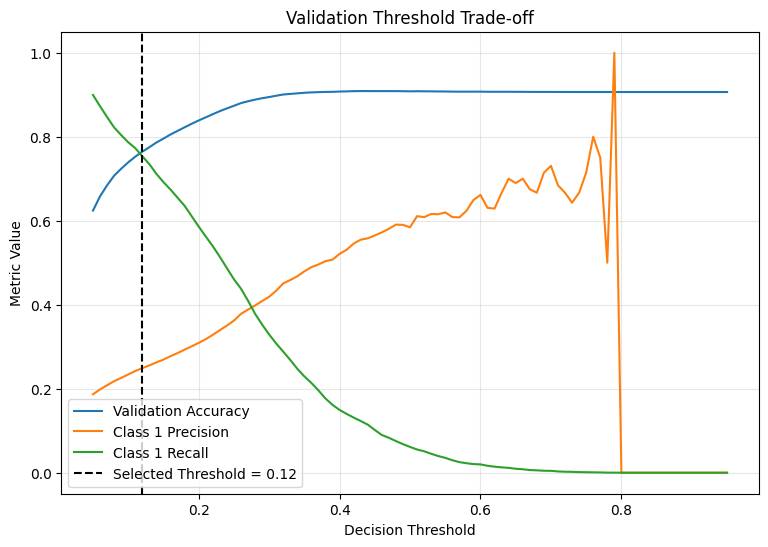

In [54]:
selected_threshold_table = (
    enhancement_threshold_tables[
        selected_positive_weight
    ]
)

plt.figure(figsize=(9, 6))
plt.plot(
    selected_threshold_table["threshold"],
    selected_threshold_table["accuracy"],
    label="Validation Accuracy",
)
plt.plot(
    selected_threshold_table["threshold"],
    selected_threshold_table["precision"],
    label="Class 1 Precision",
)
plt.plot(
    selected_threshold_table["threshold"],
    selected_threshold_table["recall"],
    label="Class 1 Recall",
)
plt.axvline(
    selected_enhanced_threshold,
    color="black",
    linestyle="--",
    label=(
        "Selected Threshold = "
        f"{selected_enhanced_threshold:.2f}"
    ),
)
plt.xlabel("Decision Threshold")
plt.ylabel("Metric Value")
plt.title("Validation Threshold Trade-off")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### 6. Evaluate the enhanced model on the test set

The selected model and threshold are now fixed. The test set is used to measure how this validation decision generalizes. The same full metric set is recorded so the enhancement cannot be judged from accuracy alone.


In [55]:
enhanced_test_probabilities = enhanced_model.predict(
    X_test_processed,
    verbose=0,
).ravel()
enhanced_test_predictions = (
    enhanced_test_probabilities
    >= selected_enhanced_threshold
).astype(int)

enhanced_test_metrics = {
    "accuracy": accuracy_score(
        y_test,
        enhanced_test_predictions,
    ),
    "precision": precision_score(
        y_test,
        enhanced_test_predictions,
        zero_division=0,
    ),
    "recall": recall_score(
        y_test,
        enhanced_test_predictions,
        zero_division=0,
    ),
    "f1": f1_score(
        y_test,
        enhanced_test_predictions,
        zero_division=0,
    ),
    "balanced_accuracy": balanced_accuracy_score(
        y_test,
        enhanced_test_predictions,
    ),
    "roc_auc": roc_auc_score(
        y_test,
        enhanced_test_probabilities,
    ),
    "pr_auc": average_precision_score(
        y_test,
        enhanced_test_probabilities,
    ),
}

for metric_name, metric_value in (
    enhanced_test_metrics.items()
):
    print(
        f"Enhanced Test {metric_name}: "
        f"{metric_value:.4f}"
    )

print("\nEnhanced confusion matrix:")
print(
    confusion_matrix(
        y_test,
        enhanced_test_predictions,
    )
)


Enhanced Test accuracy: 0.7653
Enhanced Test precision: 0.2515
Enhanced Test recall: 0.7633
Enhanced Test f1: 0.3783
Enhanced Test balanced_accuracy: 0.7644
Enhanced Test roc_auc: 0.8416
Enhanced Test pr_auc: 0.3666

Enhanced confusion matrix:
[[62787 19238]
 [ 2004  6464]]


### 7. Compare the original and enhanced neural networks

The original row uses the final regularized network and its `0.5` threshold from the documented workflow. The enhanced row uses the validation-selected class weight and threshold. Both rows are evaluated on the same test patients.


In [56]:
original_nn_metrics = {
    "model": "Original Neural Network",
    "threshold": 0.5,
    "accuracy": accuracy_score(
        y_test,
        y_pred_nn,
    ),
    "precision": precision_score(
        y_test,
        y_pred_nn,
        zero_division=0,
    ),
    "recall": recall_score(
        y_test,
        y_pred_nn,
        zero_division=0,
    ),
    "f1": f1_score(
        y_test,
        y_pred_nn,
        zero_division=0,
    ),
    "balanced_accuracy": balanced_accuracy_score(
        y_test,
        y_pred_nn,
    ),
    "roc_auc": roc_auc_score(
        y_test,
        y_prob_nn,
    ),
    "pr_auc": average_precision_score(
        y_test,
        y_prob_nn,
    ),
}

enhanced_nn_metrics = {
    "model": "Enhanced Neural Network",
    "threshold": selected_enhanced_threshold,
    **enhanced_test_metrics,
}

neural_network_comparison = pd.DataFrame([
    original_nn_metrics,
    enhanced_nn_metrics,
])

display(
    neural_network_comparison.round(4)
)


,model,threshold,accuracy,precision,recall,f1,balanced_accuracy,roc_auc,pr_auc
0,Original Neural Network,0.50,0.7038,0.2179,0.8363,0.3458,0.7632,0.8402,0.3636
1,Enhanced Neural Network,0.12,0.7653,0.2515,0.7633,0.3783,0.7644,0.8416,0.3666


## Enhancement conclusion

The validation search selected a positive-class weight of `1.00`, meaning no extra class weighting, and a decision threshold of `0.12`. On the test set, the enhanced network produced these changes:

| Metric | Original network | Enhanced network | Change |
|---|---:|---:|---:|
| Accuracy | 0.7038 | 0.7653 | +0.0615 |
| Class-1 precision | 0.2179 | 0.2515 | +0.0336 |
| Class-1 recall | 0.8363 | 0.7633 | -0.0730 |
| Class-1 F1-score | 0.3458 | 0.3783 | +0.0325 |
| Balanced accuracy | 0.7632 | 0.7644 | +0.0012 |
| ROC-AUC | 0.8402 | 0.8416 | +0.0014 |
| PR-AUC | 0.3636 | 0.3666 | +0.0030 |

False positives decrease from 25,414 to 19,238, which is the main reason accuracy and precision improve. False negatives increase from 1,386 to 2,004, so recall falls. However, test recall remains `0.7633`, above the validation rule of `0.75`.

The enhancement meets its stated goal: it improves accuracy, precision, F1-score, ROC-AUC, and PR-AUC while keeping at least three quarters of class-1 cases. It does not remove the trade-off. Better precision comes partly from making fewer positive predictions, which means missing more true cases.

The selected weight of `1.00` is also informative. For this network, aggressive class weighting was not needed once the threshold was chosen carefully. The low threshold of `0.12` still gives the unweighted model enough sensitivity to detect the minority class.


## RandomOverSampler Experiment

### Why try RandomOverSampler?

The target is imbalanced, so the training set contains many more class-0 patients than class-1 patients. A neural network sees majority examples more often and may learn a decision boundary that does not represent the minority class well.

`RandomOverSampler` addresses this by copying randomly selected minority-class training rows until a requested class ratio is reached. It changes how often the model sees existing class-1 patterns; it does not create synthetic patients.

### Important expectation

Oversampling is mainly intended to improve minority learning and recall. It does **not** guarantee higher precision. If the model starts predicting class `1` more often, false positives can increase and precision can decrease.

For that reason, this experiment combines two separate ideas:

1. Use RandomOverSampler to give the network more minority examples during training.
2. Select a precision-focused threshold on validation data while requiring recall of at least `0.60`.

The lower recall guard is deliberate. The previous enhancement already explored the high-recall policy. This new experiment asks whether we can obtain higher precision without allowing recall to collapse.

### Why use partial oversampling?

`sampling_strategy=0.5` makes the minority count half of the majority count. It does not force a 50/50 dataset. Partial oversampling is used because full balancing would duplicate many more minority rows, increase training time, and could make the model predict too many positives.

Only the neural-network training subset is oversampled. Validation and test rows remain unchanged, so they continue to represent the real class distribution. Class weights are not used in this run because combining strong class weights with oversampling would compensate for the imbalance twice.


### 1. Oversample the processed training data

`random_state=42` makes the selected duplicate rows reproducible. The count table records the class distribution before and after sampling.


In [57]:
from imblearn.over_sampling import RandomOverSampler

random_oversampler = RandomOverSampler(
    sampling_strategy=0.5,
    random_state=42,
)

X_train_ros, y_train_ros = (
    random_oversampler.fit_resample(
        X_train_nn_processed,
        y_train_nn,
    )
)

before_ros_counts = (
    pd.Series(y_train_nn)
    .value_counts()
    .sort_index()
)
after_ros_counts = (
    pd.Series(y_train_ros)
    .value_counts()
    .sort_index()
)

ros_class_distribution = pd.DataFrame({
    "before_count": before_ros_counts,
    "after_count": after_ros_counts,
})
ros_class_distribution["before_share"] = (
    ros_class_distribution["before_count"]
    / ros_class_distribution["before_count"].sum()
)
ros_class_distribution["after_share"] = (
    ros_class_distribution["after_count"]
    / ros_class_distribution["after_count"].sum()
)

display(ros_class_distribution.round(4))
print("Original training shape:", X_train_nn_processed.shape)
print("Oversampled training shape:", X_train_ros.shape)


,before_count,after_count,before_share,after_share
cardiac_disease,,,,
0,287088,287088,0.9064,0.6667
1,29636,143544,0.0936,0.3333


Original training shape: (316724, 61)
Oversampled training shape: (430632, 61)


**Recorded distribution output:**

- Before oversampling: 287,088 class-0 rows and 29,636 class-1 rows.
- After oversampling: 287,088 class-0 rows and 143,544 class-1 rows.
- The minority share increases from `9.36%` to `33.33%`.
- The training array grows from `(316724, 61)` to `(430632, 61)`.

The class-0 count does not change. RandomOverSampler adds 113,908 duplicated class-1 rows to the training data only. Validation and test shapes remain unchanged.


### 2. Train the network on oversampled data

The existing regularized architecture is reused with dropout `0.5` and learning rate `0.001`. EarlyStopping and ReduceLROnPlateau are also reused. This keeps the comparison focused on the training distribution rather than introducing another architecture change.

No `class_weight` argument is passed to `fit`. RandomOverSampler already changes the class contribution through duplicated training rows.


In [58]:
tf.keras.utils.set_random_seed(42)

ros_model = create_regularized_model(
    learning_rate=0.001,
    dropout_rate=0.5,
)

ros_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)
ros_lr_schedule = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose=1,
)

ros_history = ros_model.fit(
    X_train_ros,
    y_train_ros,
    validation_data=(
        X_val_processed,
        y_val,
    ),
    epochs=40,
    batch_size=256,
    callbacks=[
        ros_early_stopping,
        ros_lr_schedule,
    ],
    verbose=2,
)

print(
    "RandomOverSampler epochs trained:",
    len(ros_history.history["loss"]),
)


Epoch 1/40


1683/1683 - 4s - 2ms/step - accuracy: 0.7492 - auc: 0.8070 - loss: 0.5045 - val_accuracy: 0.8169 - val_auc: 0.8384 - val_loss: 0.3598 - learning_rate: 0.0010


Epoch 2/40


1683/1683 - 3s - 1ms/step - accuracy: 0.7689 - auc: 0.8320 - loss: 0.4702 - val_accuracy: 0.8126 - val_auc: 0.8388 - val_loss: 0.3639 - learning_rate: 0.0010


Epoch 3/40



Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


1683/1683 - 3s - 2ms/step - accuracy: 0.7706 - auc: 0.8342 - loss: 0.4676 - val_accuracy: 0.8201 - val_auc: 0.8394 - val_loss: 0.3604 - learning_rate: 0.0010


Epoch 4/40


1683/1683 - 3s - 2ms/step - accuracy: 0.7707 - auc: 0.8353 - loss: 0.4660 - val_accuracy: 0.8161 - val_auc: 0.8396 - val_loss: 0.3607 - learning_rate: 5.0000e-04


Epoch 5/40


1683/1683 - 3s - 2ms/step - accuracy: 0.7719 - auc: 0.8362 - loss: 0.4649 - val_accuracy: 0.8151 - val_auc: 0.8396 - val_loss: 0.3586 - learning_rate: 5.0000e-04


Epoch 6/40


1683/1683 - 3s - 2ms/step - accuracy: 0.7719 - auc: 0.8363 - loss: 0.4649 - val_accuracy: 0.8137 - val_auc: 0.8397 - val_loss: 0.3606 - learning_rate: 5.0000e-04


Epoch 7/40



Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


1683/1683 - 2s - 1ms/step - accuracy: 0.7720 - auc: 0.8366 - loss: 0.4642 - val_accuracy: 0.8149 - val_auc: 0.8396 - val_loss: 0.3603 - learning_rate: 5.0000e-04


Epoch 8/40


1683/1683 - 2s - 1ms/step - accuracy: 0.7723 - auc: 0.8371 - loss: 0.4639 - val_accuracy: 0.8148 - val_auc: 0.8396 - val_loss: 0.3586 - learning_rate: 2.5000e-04


Epoch 9/40



Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


1683/1683 - 2s - 1ms/step - accuracy: 0.7727 - auc: 0.8374 - loss: 0.4633 - val_accuracy: 0.8155 - val_auc: 0.8396 - val_loss: 0.3596 - learning_rate: 2.5000e-04


Epoch 10/40


1683/1683 - 2s - 1ms/step - accuracy: 0.7729 - auc: 0.8380 - loss: 0.4626 - val_accuracy: 0.8147 - val_auc: 0.8396 - val_loss: 0.3587 - learning_rate: 1.2500e-04


Epoch 11/40


1683/1683 - 2s - 1ms/step - accuracy: 0.7727 - auc: 0.8377 - loss: 0.4630 - val_accuracy: 0.8153 - val_auc: 0.8396 - val_loss: 0.3582 - learning_rate: 1.2500e-04


Epoch 12/40


1683/1683 - 2s - 1ms/step - accuracy: 0.7728 - auc: 0.8380 - loss: 0.4626 - val_accuracy: 0.8156 - val_auc: 0.8395 - val_loss: 0.3576 - learning_rate: 1.2500e-04


Epoch 13/40


1683/1683 - 2s - 1ms/step - accuracy: 0.7733 - auc: 0.8380 - loss: 0.4627 - val_accuracy: 0.8159 - val_auc: 0.8395 - val_loss: 0.3575 - learning_rate: 1.2500e-04


Epoch 14/40


1683/1683 - 2s - 1ms/step - accuracy: 0.7729 - auc: 0.8379 - loss: 0.4626 - val_accuracy: 0.8157 - val_auc: 0.8395 - val_loss: 0.3574 - learning_rate: 1.2500e-04


Epoch 15/40



Epoch 15: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.


1683/1683 - 2s - 1ms/step - accuracy: 0.7733 - auc: 0.8382 - loss: 0.4625 - val_accuracy: 0.8156 - val_auc: 0.8395 - val_loss: 0.3577 - learning_rate: 1.2500e-04


Epoch 16/40


1683/1683 - 2s - 1ms/step - accuracy: 0.7736 - auc: 0.8381 - loss: 0.4625 - val_accuracy: 0.8160 - val_auc: 0.8395 - val_loss: 0.3577 - learning_rate: 6.2500e-05


Epoch 17/40



Epoch 17: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.


1683/1683 - 2s - 1ms/step - accuracy: 0.7731 - auc: 0.8382 - loss: 0.4623 - val_accuracy: 0.8154 - val_auc: 0.8394 - val_loss: 0.3576 - learning_rate: 6.2500e-05


Epoch 18/40


1683/1683 - 2s - 1ms/step - accuracy: 0.7734 - auc: 0.8386 - loss: 0.4619 - val_accuracy: 0.8156 - val_auc: 0.8395 - val_loss: 0.3576 - learning_rate: 3.1250e-05


Epoch 19/40



Epoch 19: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.


1683/1683 - 2s - 1ms/step - accuracy: 0.7734 - auc: 0.8384 - loss: 0.4620 - val_accuracy: 0.8151 - val_auc: 0.8395 - val_loss: 0.3577 - learning_rate: 3.1250e-05


RandomOverSampler epochs trained: 19


### 3. Read and plot the oversampled training behavior

The RandomOverSampler model trains for 19 epochs. Validation loss improves from `0.3598` in epoch 1 to its lowest area near `0.3574`. ReduceLROnPlateau gradually lowers the learning rate when progress stalls, and EarlyStopping ends training after five later epochs fail to establish a new best validation loss.

Training ROC-AUC continues improving slowly, while validation ROC-AUC remains around `0.8395`. The following loss plot checks whether duplicated minority rows improve validation behavior or mainly help the model fit the resampled training data.


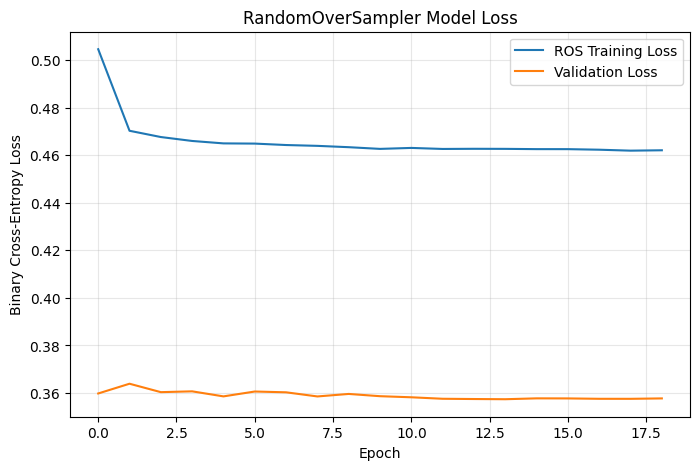

In [59]:
plt.figure(figsize=(8, 5))
plt.plot(
    ros_history.history["loss"],
    label="ROS Training Loss",
)
plt.plot(
    ros_history.history["val_loss"],
    label="Validation Loss",
)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("RandomOverSampler Model Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### 4. Compare recall-safe and precision-focused thresholds

First, the same `0.75` recall rule from the previous enhancement is applied for a fair high-recall comparison. A second policy then requires recall of at least `0.60` and selects the threshold with the highest precision. F1-score and accuracy break ties.

This second policy directly targets the requested precision improvement, while the recall floor prevents a trivial solution that predicts almost no positive cases.


In [60]:
ros_validation_probabilities = ros_model.predict(
    X_val_processed,
    verbose=0,
).ravel()

ros_recall_safe_selection, ros_threshold_table = (
    select_threshold_with_recall_guard(
        y_val,
        ros_validation_probabilities,
        minimum_recall=0.75,
    )
)

ros_precision_candidates = ros_threshold_table[
    ros_threshold_table["recall"] >= 0.60
]
ros_precision_selection = (
    ros_precision_candidates
    .sort_values(
        ["precision", "f1", "accuracy"],
        ascending=False,
    )
    .iloc[0]
)

ros_threshold_policies = pd.DataFrame([
    {
        "policy": "Recall-safe",
        **ros_recall_safe_selection.to_dict(),
    },
    {
        "policy": "Precision-focused",
        **ros_precision_selection.to_dict(),
    },
])

display(ros_threshold_policies.round(4))


,policy,threshold,accuracy,precision,recall,f1,balanced_accuracy
0,Recall-safe,0.41,0.7652,0.2499,0.7541,0.3754,0.7602
1,Precision-focused,0.53,0.8337,0.3035,0.6001,0.4031,0.7290


**Recorded validation policies:**

| Policy | Threshold | Accuracy | Precision | Recall | F1-score | Balanced accuracy |
|---|---:|---:|---:|---:|---:|---:|
| Recall-safe | 0.41 | 0.7652 | 0.2499 | 0.7541 | 0.3754 | 0.7602 |
| Precision-focused | 0.53 | 0.8337 | 0.3035 | 0.6001 | 0.4031 | 0.7290 |

The recall-safe policy behaves like the previous enhancement: it keeps roughly three quarters of class-1 cases and reaches about 25% precision. Raising the threshold to `0.53` under the `0.60` recall guard increases validation precision to `0.3035` and F1-score to `0.4031`, but balanced accuracy falls because minority recall is lower.


### 5. Visualize the RandomOverSampler threshold trade-off


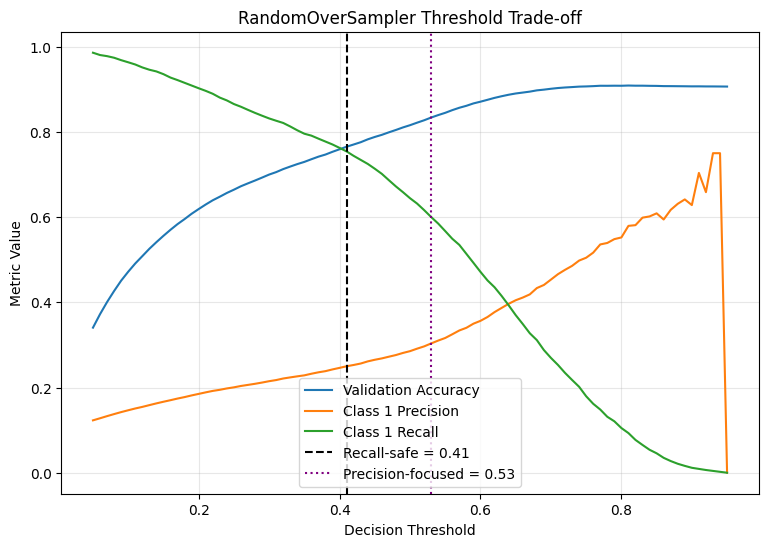

In [61]:
ros_recall_safe_threshold = float(
    ros_recall_safe_selection["threshold"]
)
ros_precision_threshold = float(
    ros_precision_selection["threshold"]
)

plt.figure(figsize=(9, 6))
plt.plot(
    ros_threshold_table["threshold"],
    ros_threshold_table["accuracy"],
    label="Validation Accuracy",
)
plt.plot(
    ros_threshold_table["threshold"],
    ros_threshold_table["precision"],
    label="Class 1 Precision",
)
plt.plot(
    ros_threshold_table["threshold"],
    ros_threshold_table["recall"],
    label="Class 1 Recall",
)
plt.axvline(
    ros_recall_safe_threshold,
    color="black",
    linestyle="--",
    label=(
        "Recall-safe = "
        f"{ros_recall_safe_threshold:.2f}"
    ),
)
plt.axvline(
    ros_precision_threshold,
    color="purple",
    linestyle=":",
    label=(
        "Precision-focused = "
        f"{ros_precision_threshold:.2f}"
    ),
)
plt.xlabel("Decision Threshold")
plt.ylabel("Metric Value")
plt.title("RandomOverSampler Threshold Trade-off")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### 6. Evaluate both RandomOverSampler policies on test data

Both thresholds were fixed from validation results before this cell. Evaluating both policies shows whether the precision gain generalizes and makes its recall cost visible.


In [62]:
ros_test_probabilities = ros_model.predict(
    X_test_processed,
    verbose=0,
).ravel()


def evaluate_ros_policy(
    policy_name,
    threshold,
):
    predictions = (
        ros_test_probabilities >= threshold
    ).astype(int)

    return {
        "model": policy_name,
        "threshold": threshold,
        "accuracy": accuracy_score(
            y_test,
            predictions,
        ),
        "precision": precision_score(
            y_test,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            y_test,
            predictions,
            zero_division=0,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_test,
            predictions,
        ),
        "roc_auc": roc_auc_score(
            y_test,
            ros_test_probabilities,
        ),
        "pr_auc": average_precision_score(
            y_test,
            ros_test_probabilities,
        ),
        "confusion_matrix": confusion_matrix(
            y_test,
            predictions,
        ),
    }


ros_recall_safe_test = evaluate_ros_policy(
    "ROS Recall-safe",
    ros_recall_safe_threshold,
)
ros_precision_test = evaluate_ros_policy(
    "ROS Precision-focused",
    ros_precision_threshold,
)

for result in [
    ros_recall_safe_test,
    ros_precision_test,
]:
    print(f"\n{result['model']}")
    print(
        "Threshold:",
        f"{result['threshold']:.2f}",
    )
    print(
        "Accuracy:",
        f"{result['accuracy']:.4f}",
    )
    print(
        "Precision:",
        f"{result['precision']:.4f}",
    )
    print(
        "Recall:",
        f"{result['recall']:.4f}",
    )
    print(
        "F1:",
        f"{result['f1']:.4f}",
    )
    print("Confusion matrix:")
    print(result["confusion_matrix"])



ROS Recall-safe
Threshold: 0.41
Accuracy: 0.7661
Precision: 0.2517
Recall: 0.7600
F1: 0.3782
Confusion matrix:
[[62890 19135]
 [ 2032  6436]]

ROS Precision-focused
Threshold: 0.53
Accuracy: 0.8346
Precision: 0.3061
Recall: 0.6063
F1: 0.4068
Confusion matrix:
[[70387 11638]
 [ 3334  5134]]


### 7. Final comparison

The comparison includes the original model, the first enhanced model, and both RandomOverSampler decision policies. Confusion matrices are excluded from the table because they are displayed separately above.


In [63]:
ros_comparison_rows = []

for result in [
    ros_recall_safe_test,
    ros_precision_test,
]:
    ros_comparison_rows.append({
        key: value
        for key, value in result.items()
        if key != "confusion_matrix"
    })

final_ros_comparison = pd.concat([
    neural_network_comparison,
    pd.DataFrame(ros_comparison_rows),
], ignore_index=True)

display(final_ros_comparison.round(4))


,model,threshold,accuracy,precision,recall,f1,balanced_accuracy,roc_auc,pr_auc
0,Original Neural Network,0.50,0.7038,0.2179,0.8363,0.3458,0.7632,0.8402,0.3636
1,Enhanced Neural Network,0.12,0.7653,0.2515,0.7633,0.3783,0.7644,0.8416,0.3666
2,ROS Recall-safe,0.41,0.7661,0.2517,0.7600,0.3782,0.7634,0.8415,0.3661
3,ROS Precision-focused,0.53,0.8346,0.3061,0.6063,0.4068,0.7322,0.8415,0.3661


## RandomOverSampler conclusion

The RandomOverSampler experiment runs successfully and improves precision under the precision-focused decision policy.

| Model or policy | Threshold | Accuracy | Precision | Recall | F1-score | Balanced accuracy | ROC-AUC | PR-AUC |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Original Neural Network | 0.50 | 0.7038 | 0.2179 | 0.8363 | 0.3458 | 0.7632 | 0.8402 | 0.3636 |
| Enhanced Neural Network | 0.12 | 0.7653 | 0.2515 | 0.7633 | 0.3783 | 0.7644 | 0.8416 | 0.3666 |
| ROS Recall-safe | 0.41 | 0.7661 | 0.2517 | 0.7600 | 0.3782 | 0.7634 | 0.8415 | 0.3661 |
| ROS Precision-focused | 0.53 | 0.8346 | 0.3061 | 0.6063 | 0.4068 | 0.7322 | 0.8415 | 0.3661 |

### What improved

Compared with the first enhanced network, the precision-focused ROS policy:

- Raises accuracy from `0.7653` to `0.8346`.
- Raises precision from `0.2515` to `0.3061`.
- Raises F1-score from `0.3783` to `0.4068`.
- Reduces false positives from 19,238 to 11,638.

### What was lost

- Recall falls from `0.7633` to `0.6063`.
- False negatives increase from 2,004 to 3,334.
- Balanced accuracy falls from `0.7644` to `0.7322`.

### Did RandomOverSampler itself raise precision?

Not by much under the same high-recall goal. The ROS recall-safe policy reaches precision `0.2517`, almost identical to the enhanced network's `0.2515`. ROC-AUC and PR-AUC are also nearly unchanged. This means oversampling did not materially improve probability ranking.

The larger precision gain comes from combining the oversampled model with the higher validation-selected threshold of `0.53`. That threshold produces fewer positive predictions, which removes many false positives but also misses more true class-1 cases.

### Final interpretation

RandomOverSampler is useful as a controlled imbalance experiment, but it is not a free precision improvement. If the project values detecting as many possible cardiac-disease cases as possible, the enhanced network or ROS recall-safe policy is more appropriate. If reducing false alarms is more important and recall near 60% is acceptable, the ROS precision-focused policy provides the best accuracy, precision, and F1-score in this notebook.

This threshold choice is a modeling trade-off only. It is not a clinically validated operating point.
